In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/content/Players.xlsx")

In [3]:
df

,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN
...,...,...,...,...,...
561,Younis Khan,1977-11-29,Right_Hand,Right-arm medium,Pakistan
562,YS Chahal,1990-07-23,Right_Hand,Legbreak googly,India
563,Yuvraj Singh,1981-12-12,Left_Hand,Slow left-arm orthodox,India
564,YV Takawale,1984-11-05,Right_Hand,NaN,India


In [4]:
df.head()

,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
0,A Ashish Reddy,1991-02-24,Right_Hand,Right-arm medium,India
1,A Chandila,1983-12-05,Right_Hand,Right-arm offbreak,India
2,A Chopra,1977-09-19,Right_Hand,Right-arm offbreak,India
3,A Choudhary,NaT,Right_hand,Left-arm fast-medium,NaN
4,A Dananjaya,NaT,Right_Hand,Right-arm offbreak,NaN


In [5]:
df.tail()

,Player_Name,DOB,Batting_Hand,Bowling_Skill,Country
561,Younis Khan,1977-11-29,Right_Hand,Right-arm medium,Pakistan
562,YS Chahal,1990-07-23,Right_Hand,Legbreak googly,India
563,Yuvraj Singh,1981-12-12,Left_Hand,Slow left-arm orthodox,India
564,YV Takawale,1984-11-05,Right_Hand,NaN,India
565,Z Khan,1978-10-07,Right_Hand,Left-arm fast-medium,India


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Player_Name    566 non-null    object        
 1   DOB            471 non-null    datetime64[ns]
 2   Batting_Hand   563 non-null    object        
 3   Bowling_Skill  502 non-null    object        
 4   Country        471 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 22.2+ KB


In [7]:
df.isnull().sum()

,0
Player_Name,0
DOB,95
Batting_Hand,3
Bowling_Skill,64
Country,95


In [8]:
df['Country'].fillna("Unknown", inplace=True)
df['Batting_Hand'].fillna(df['Batting_Hand'].mode()[0], inplace=True)
df['Bowling_Skill'].fillna(df['Bowling_Skill'].mode()[0], inplace=True)

/tmp/ipykernel_10570/4016383769.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Country'].fillna("Unknown", inplace=True)
/tmp/ipykernel_10570/4016383769.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [9]:
df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')

current_year = pd.Timestamp.now().year

df['Age'] = current_year - df['DOB'].dt.year

In [10]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_10570/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [11]:
df.drop(['Player_Name', 'DOB'], axis=1, inplace=True)

In [12]:
from sklearn.preprocessing import LabelEncoder

le_batting = LabelEncoder()
le_bowling = LabelEncoder()
le_country = LabelEncoder()

df['Batting_Hand'] = le_batting.fit_transform(df['Batting_Hand'])
df['Bowling_Skill'] = le_bowling.fit_transform(df['Bowling_Skill'])
df['Country'] = le_country.fit_transform(df['Country'])

In [13]:
df

,Batting_Hand,Bowling_Skill,Country,Age
0,1,11,3,35.0
1,1,13,3,43.0
2,1,13,3,49.0
3,2,1,9,41.0
4,1,13,9,41.0
...,...,...,...,...
561,1,11,6,49.0
562,1,5,3,36.0
563,0,15,3,45.0
564,1,11,3,42.0


In [14]:
df.head()

,Batting_Hand,Bowling_Skill,Country,Age
0,1,11,3,35.0
1,1,13,3,43.0
2,1,13,3,49.0
3,2,1,9,41.0
4,1,13,9,41.0


In [15]:
df.tail()

,Batting_Hand,Bowling_Skill,Country,Age
561,1,11,6,49.0
562,1,5,3,36.0
563,0,15,3,45.0
564,1,11,3,42.0
565,1,1,3,48.0


In [16]:
X = df[['Batting_Hand', 'Bowling_Skill', 'Age']]
y = df['Country']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [19]:
dt_pred = dt_model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.543859649122807


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [22]:
rf_pred = rf_model.predict(X_test)

In [23]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.5701754385964912


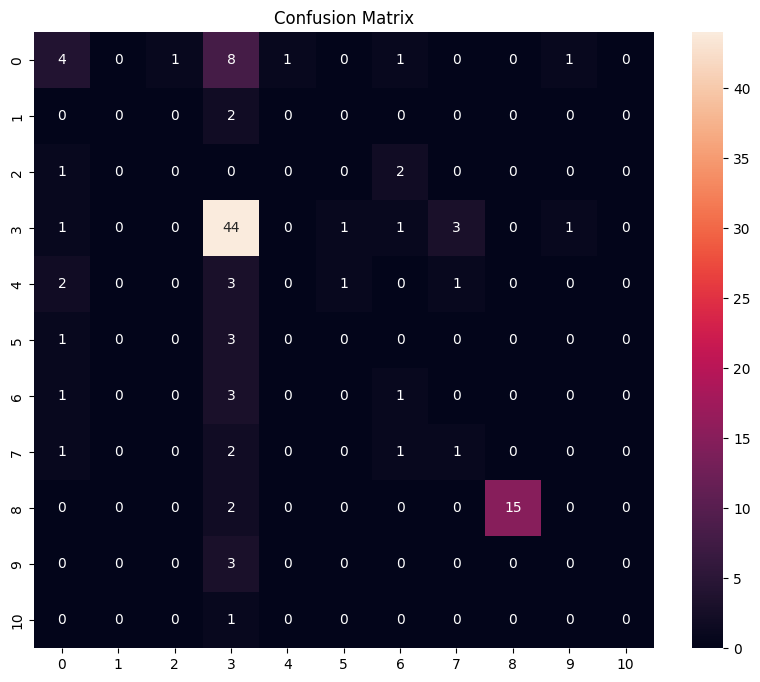

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.36      0.25      0.30        16
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         3
           3       0.62      0.86      0.72        51
           5       0.00      0.00      0.00         7
           6       0.00      0.00      0.00         4
           7       0.17      0.20      0.18         5
           8       0.20      0.20      0.20         5
           9       1.00      0.88      0.94        17
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         1

    accuracy                           0.57       114
   macro avg       0.21      0.22      0.21       114
weighted avg       0.49      0.57      0.52       114



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


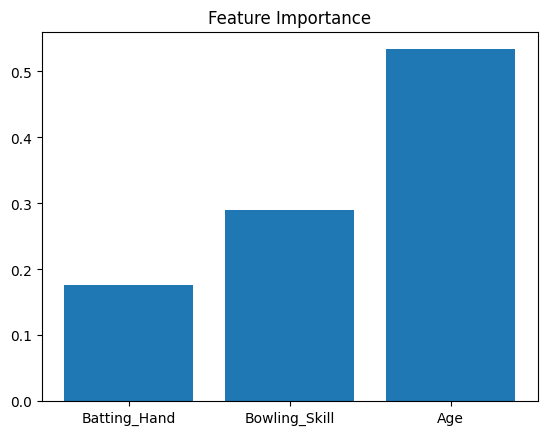

In [26]:
importance = rf_model.feature_importances_

features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

In [27]:
sample = [[1, 5, 28]]

prediction = rf_model.predict(sample)

print("Predicted Country:",
      le_country.inverse_transform(prediction))

Predicted Country: ['India']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
